In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [2]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [3]:
print(list(Path("data").glob("*.csv")))

[PosixPath('data/DZA_selected.csv'), PosixPath('data/IND_SL.TLF.CACT.MA.ZS.csv'), PosixPath('data/MAR_raw.csv'), PosixPath('data/IND_SL.TLF.CACT.FE.ZS.csv'), PosixPath('data/KWT_raw.csv'), PosixPath('data/IND_SP.DYN.CONU.ZS.csv'), PosixPath('data/OMN_selected.csv'), PosixPath('data/QAT_raw.csv'), PosixPath('data/MAR_selected.csv'), PosixPath('data/IND_SP.DYN.CONM.ZS.csv'), PosixPath('data/all_countries_selected.csv'), PosixPath('data/IND_SH.STA.MMRT.csv'), PosixPath('data/IND_SG.IND.WORK.EQ.csv'), PosixPath('data/IND_SE.ADT.1524.LT.FE.ZS.csv'), PosixPath('data/BHR_raw.csv'), PosixPath('data/IND_SE.ADT.1524.LT.MA.ZS.csv'), PosixPath('data/KWT_selected.csv'), PosixPath('data/IND_SG.CNT.SIGN.EQ.csv'), PosixPath('data/all_countries_combined.csv'), PosixPath('data/LBY_selected.csv'), PosixPath('data/IRQ_selected.csv'), PosixPath('data/IND_SE.ENR.SECO.FM.ZS.csv'), PosixPath('data/IND_SG.HLD.HEAD.EQ.csv'), PosixPath('data/IND_SG.REM.RIGT.EQ.csv'), PosixPath('data/BHR_selected.csv'), PosixPath

In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/all_countries_selected.csv")
meta = pd.read_csv("data/indicator_metadata_with_units.csv")

## Basic Data Exploration

In [5]:
df.head()  

,year,value,country_id,country_name,indicator_id,indicator_name,unit_type
0,2024,NaN,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
1,2023,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
2,2022,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
3,2021,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
4,2020,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)


In [6]:
df.rename(columns={'unit_type':'Unit_Type','year':"Year","value":"Value",
                   "country_name":"Country",'indicator_id':"Indicator Code",
                   "country_id":"Country Code","indicator_name":"Indicator Name"}, inplace=True)

In [7]:
df.rename(columns = {"Unit_Type":"Unit Type"}, inplace=True)

In [8]:
df.head()

,Year,Value,Country Code,Country,Indicator Code,Indicator Name,Unit Type
0,2024,NaN,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
1,2023,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
2,2022,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
3,2021,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
4,2020,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)


In [9]:
columns_order = ['Country','Country Code', 'Year', 'Indicator Code', 'Indicator Name', 'Value', "Unit Type"]
df = df[columns_order]

In [10]:
df['Unit Type'].unique()

array(['Binary (1/0)', 'Index / Score', 'Rate per 100,000', 'Percent (%)',
       'Rate per 1,000', 'Currency (US$)', 'Years'], dtype=object)

In [11]:
df.shape

(14625, 7)

In [12]:
df.duplicated().sum()

0

In [13]:
df.isna().sum()

Country              0
Country Code         0
Year                 0
Indicator Code       0
Indicator Name       0
Value             3621
Unit Type            0
dtype: int64

## Exploring Missing Data

In [14]:
empty_indicators = (
    df.groupby("Indicator Code")["Value"]
    .apply(lambda x: x.isna().all())
)

# Filter only True (completely missing indicators)
empty_indicators = empty_indicators[empty_indicators].index.tolist()

print(f"Indicators with no data: {len(empty_indicators)}")
print(empty_indicators[:10]) 

Indicators with no data: 0
[]


In [15]:
df["Value"].isna().sum(), df["Value"].isna().mean()

(3621, 0.2475897435897436)

In [16]:
df.groupby("Indicator Name")["Value"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(20)


Indicator Name
Women who were first married by age 18 (% of women ages 20-24)                                         305
Women who were first married by age 15 (% of women ages 20-24)                                         305
Contraceptive prevalence, any modern method (% of married women ages 15-49)                            283
Contraceptive prevalence, any method (% of married women ages 15-49)                                   281
Literacy rate, adult male (% of males ages 15 and above)                                               245
Literacy rate, adult total (% of people ages 15 and above)                                             245
Literacy rate, youth male (% of males ages 15-24)                                                      244
Literacy rate, adult female (% of females ages 15 and above)                                           242
Literacy rate, youth female (% of females ages 15-24)                                                  236
Educational attainment

In [17]:
df.groupby("Country")["Value"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(10)


Country
Libya           347
Yemen, Rep.     333
Iraq            296
Algeria         292
Bahrain         291
Morocco         280
Qatar           271
Saudi Arabia    270
Oman            262
Kuwait          259
Name: Value, dtype: int64

<Axes: title={'center': 'Missing Values by Year'}, xlabel='Year'>

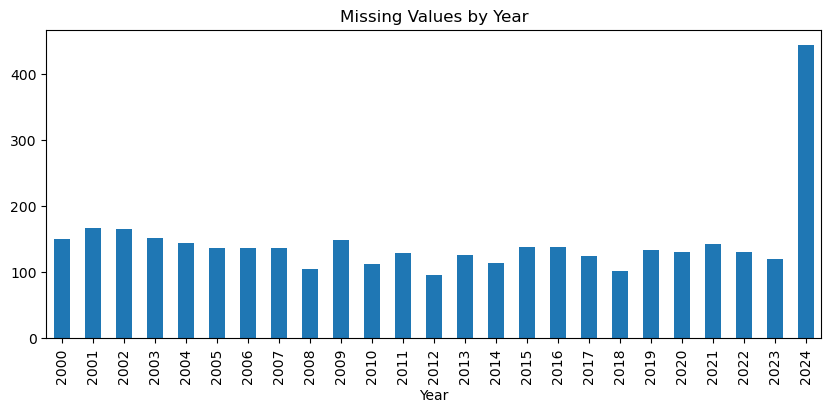

In [18]:
df.groupby("Year")["Value"].apply(lambda x: x.isna().sum()).plot(kind="bar", figsize=(10,4), title="Missing Values by Year")


In [19]:
df.groupby("Year")["Value"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head()


Year
2024    444
2001    167
2002    166
2003    152
2000    150
Name: Value, dtype: int64

In [20]:
df = df[df["Year"] != 2024].copy()

In [21]:
df["Year"].unique()
df["Year"].max()


2023

In [22]:
print(df.shape)


(14040, 7)


In [23]:
df["Value"].isna().sum(), df["Value"].isna().mean()


(3177, 0.22628205128205128)

In [24]:
df.groupby("Indicator Code")["Value"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(20)

Indicator Code
SP.M18.2024.FE.ZS       292
SP.M15.2024.FE.ZS       292
SP.DYN.CONM.ZS          270
SP.DYN.CONU.ZS          268
SE.ADT.LITR.MA.ZS       234
SE.ADT.LITR.ZS          234
SE.ADT.1524.LT.MA.ZS    233
SE.ADT.LITR.FE.ZS       231
SE.ADT.1524.LT.FE.ZS    225
SE.SEC.CUAT.UP.MA.ZS    217
SE.SEC.CUAT.UP.FE.ZS    216
SG.GEN.MNST.ZS          162
SE.ENR.SECO.FM.ZS       150
FP.CPI.TOTL.ZG          120
SG.GEN.PARL.ZS           28
NY.GDP.PCAP.CD            5
SG.DNG.WORK.DN.EQ         0
SL.SRV.EMPL.FE.ZS         0
SG.APL.PSPT.EQ            0
SP.DYN.LE00.MA.IN         0
Name: Value, dtype: int64

In [25]:
inds = ["SP.M18.2024.FE.ZS", "SP.M15.2024.FE.ZS","SP.DYN.CONM.ZS", "SP.DYN.CONU.ZS"]

subset = df[df["Indicator Code"].isin(inds)]

missing_by_country = (
    subset.groupby(["Indicator Code", "Country"])["Value"]
    .apply(lambda x: x.isna().sum())
    .reset_index(name="missing_count")
)
missing_by_country.sort_values(["Indicator Code", "missing_count"], ascending=[True, False]).head(20)


,Indicator Code,Country,missing_count
1,SP.DYN.CONM.ZS,Bahrain,24
5,SP.DYN.CONM.ZS,Kuwait,24
9,SP.DYN.CONM.ZS,Qatar,23
6,SP.DYN.CONM.ZS,Libya,21
7,SP.DYN.CONM.ZS,Morocco,21
8,SP.DYN.CONM.ZS,Oman,21
10,SP.DYN.CONM.ZS,Saudi Arabia,21
12,SP.DYN.CONM.ZS,"Yemen, Rep.",21
3,SP.DYN.CONM.ZS,Iraq,20
0,SP.DYN.CONM.ZS,Algeria,19


In [26]:
missing_by_country["total_rows"] = (
    subset.groupby(["Indicator Code", "Country"])["Value"].transform("count")
)
missing_by_country["missing_rate"] = (
    missing_by_country["missing_count"] / missing_by_country["total_rows"]
)

missing_by_country.sort_values(["Indicator Code", "missing_rate"], ascending=[True, False]).head(10)


,Indicator Code,Country,missing_count,total_rows,missing_rate
0,SP.DYN.CONM.ZS,Algeria,19,NaN,NaN
1,SP.DYN.CONM.ZS,Bahrain,24,NaN,NaN
2,SP.DYN.CONM.ZS,"Egypt, Arab Rep.",19,NaN,NaN
3,SP.DYN.CONM.ZS,Iraq,20,NaN,NaN
4,SP.DYN.CONM.ZS,Jordan,18,NaN,NaN
5,SP.DYN.CONM.ZS,Kuwait,24,NaN,NaN
6,SP.DYN.CONM.ZS,Libya,21,NaN,NaN
7,SP.DYN.CONM.ZS,Morocco,21,NaN,NaN
8,SP.DYN.CONM.ZS,Oman,21,NaN,NaN
9,SP.DYN.CONM.ZS,Qatar,23,NaN,NaN


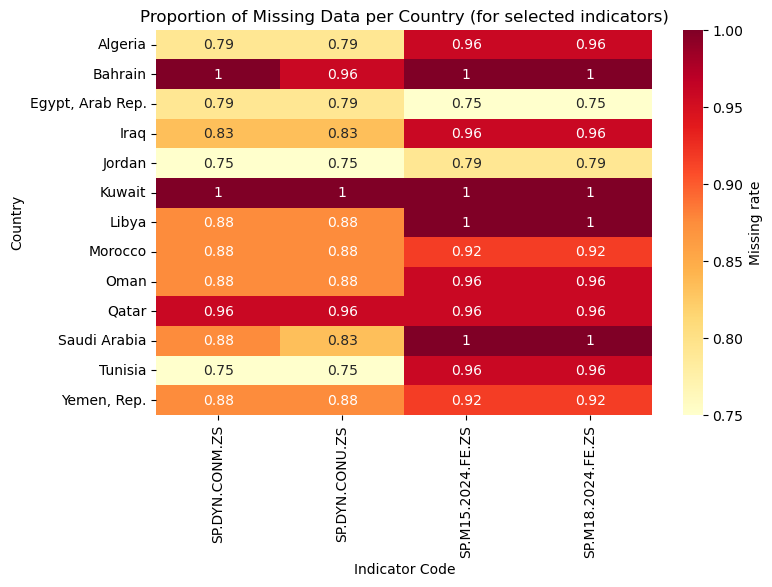

In [27]:
pivot = subset.pivot_table(
    values="Value",
    index="Country",
    columns="Indicator Code",
    aggfunc=lambda x: x.isna().mean()
)
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap="YlOrRd", cbar_kws={'label': 'Missing rate'})
plt.title("Proportion of Missing Data per Country (for selected indicators)")
plt.show()


In [28]:
null_summary = (
    df.groupby("Indicator Code")["Value"]
    .agg([("missing_count", lambda x: x.isna().sum()),
          ("missing_rate", lambda x: x.isna().mean()),
          ("years_tracked", "count")])
    .reset_index()
    .sort_values("missing_rate", ascending=False)
)
null_summary.head(10)


,Indicator Code,missing_count,missing_rate,years_tracked
44,SP.M18.2024.FE.ZS,292,0.935897,20
43,SP.M15.2024.FE.ZS,292,0.935897,20
39,SP.DYN.CONM.ZS,270,0.865385,42
40,SP.DYN.CONU.ZS,268,0.858974,44
5,SE.ADT.LITR.MA.ZS,234,0.750000,78
6,SE.ADT.LITR.ZS,234,0.750000,78
3,SE.ADT.1524.LT.MA.ZS,233,0.746795,79
4,SE.ADT.LITR.FE.ZS,231,0.740385,81
2,SE.ADT.1524.LT.FE.ZS,225,0.721154,87
9,SE.SEC.CUAT.UP.MA.ZS,217,0.695513,95


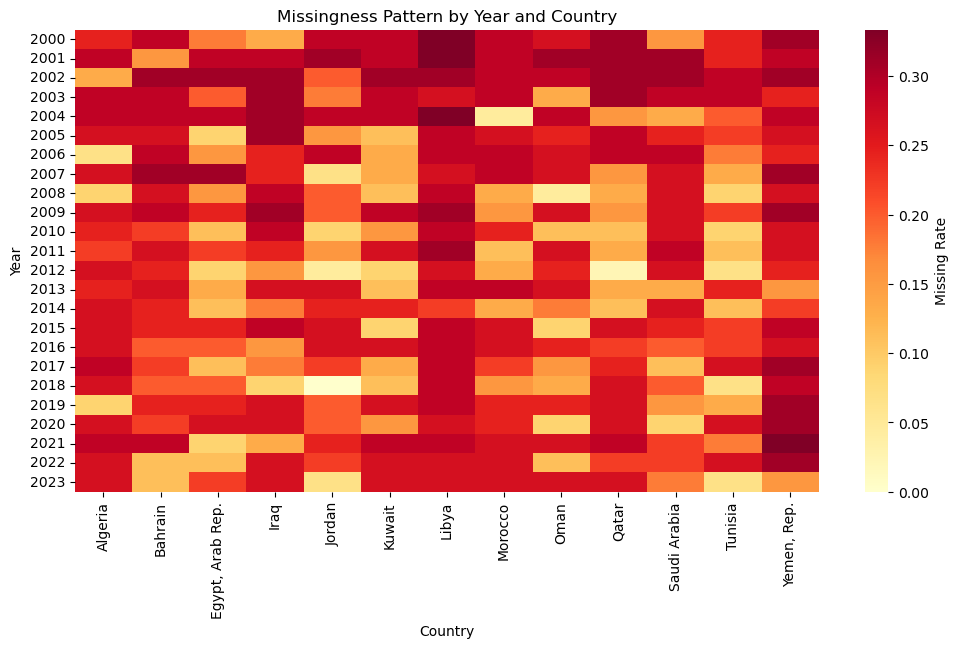

In [29]:
pivot = (
    df.pivot_table(values="Value", index="Year", columns="Country", aggfunc=lambda x: x.isna().mean())
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={'label': 'Missing Rate'})
plt.title("Missingness Pattern by Year and Country")
plt.show()


Horizontal streaks (same country missing many years) → use forward/backward fill.

Random holes → interpolation.

Isolated countries/indicators → leave null or regional average.

In [30]:
df.isna().sum()

Country              0
Country Code         0
Year                 0
Indicator Code       0
Indicator Name       0
Value             3177
Unit Type            0
dtype: int64

# Framework for Dealing with Null Values

### Prep

In [31]:
df = df.sort_values(by=["Country", "Indicator Code", "Year"]).reset_index(drop=True)

### Drop Unreliable Indicators

In [32]:
to_drop = ["SP.M18.2024.FE.ZS","SP.M15.2024.FE.ZS","SP.DYN.CONM.ZS","SP.DYN.CONU.ZS"]
df = df[~df["Indicator Code"].isin(to_drop)]

In [33]:
print(df["Indicator Code"].isin(to_drop).sum())


0


In [35]:
df.isna().sum()

Country              0
Country Code         0
Year                 0
Indicator Code       0
Indicator Name       0
Value             2055
Unit Type            0
dtype: int64

In [36]:
def classify_series(s:pd.Series) -> dict:
    """
    s is the Value series for a single (Indicator Code, Country Code),
    indexed by Year (sorted).
    """
    
    #Basic stats
    n= len(s)
    miss_rate = s.isna().mean()
    valid = s.notna().sum()
    res = {'missing_rate':miss_rate, "n":n, "valid":valid}
    
    if valid ==0:
        res["pattern"] = "all_missing"
        res["method"] = "drop_group"
        return res
    
    first_valid_pos = s.first_valid_index()
    last_valid_pos = s.last_valid_index()
    
     # Booleans for edge/internal gaps
    leading_gap  = s.loc[:first_valid_pos].iloc[:-1].isna().any() if first_valid_pos is not None else False
    trailing_gap = s.loc[last_valid_pos:].iloc[1:].isna().any()   if last_valid_pos  is not None else False
    
    internal_gap = False
    if first_valid_pos is not None and last_valid_pos is not None and first_valid_pos != last_valid_pos:
        internal_gap = s.loc[first_valid_pos:last_valid_pos].isna().any()
        
    if miss_rate >=0.90:
        res["pattern"] = "predominantly_missing"
        res["method"] = "leave_null"
    elif not leading_gap and trailing_gap and not internal_gap:
        res["pattern"] = "tail_only_missing"
        res["method"] = "ffill"
    elif leading_gap and not trailing_gap and not internal_gap:
        res["pattern"] = "head_only_missing"
        res["method"] = "bfill"
    elif internal_gap and miss_rate <=0.5:
        res["pattern"] = "internal_gaps"
        res["method"] = "interpolate"
    elif miss_rate<=0.15:
        res["pattern"] = "scatterd_low"
        res["method"] = "mean_by_group"
    elif miss_rate<0.5:
        res["pattern"] = "scatterd_mid"
        res["method"] = "interpolate"
    else:
        res["pattern"] = "very_sparse"
        res["method"] = "leave_null"
    return res

plan_records = []
for (ind, ctry), g in df.groupby(["Indicator Code", "Country"]):
    s = g.set_index("Year")["Value"].sort_index()
    classification = classify_series(s)
    classification.update({"Indicator Code":ind, "Country":ctry})
    plan_records.append(classification)

plan = pd.DataFrame(plan_records).sort_values(["method", "missing_rate"])
plan.head(10)

,missing_rate,n,valid,pattern,method,Indicator Code,Country
8,0.083333,24,22,head_only_missing,bfill,FP.CPI.TOTL.ZG,Oman
209,0.125000,24,21,head_only_missing,bfill,SG.GEN.PARL.ZS,Bahrain
218,0.125000,24,21,head_only_missing,bfill,SG.GEN.PARL.ZS,Saudi Arabia
216,0.166667,24,20,head_only_missing,bfill,SG.GEN.PARL.ZS,Oman
0,0.250000,24,18,head_only_missing,bfill,FP.CPI.TOTL.ZG,Algeria
11,0.250000,24,18,head_only_missing,bfill,FP.CPI.TOTL.ZG,Tunisia
217,0.250000,24,18,head_only_missing,bfill,SG.GEN.PARL.ZS,Qatar
4,0.291667,24,17,head_only_missing,bfill,FP.CPI.TOTL.ZG,Jordan
7,0.333333,24,16,head_only_missing,bfill,FP.CPI.TOTL.ZG,Morocco
1,0.458333,24,13,head_only_missing,bfill,FP.CPI.TOTL.ZG,Bahrain


In [37]:
# Drop groups marked drop_group

drop_keys = set(zip(plan.loc[plan["method"]=="drop_group","Indicator Code"],
                    plan.loc[plan["method"]=="drop_group","Country"]))
mask = df[["Indicator Code","Country"]].apply(tuple, axis=1).isin(drop_keys)
df = df[~mask].copy()



In [38]:
# Build a lookup for methods
method_map = {(r["Indicator Code"], r["Country"]): r["method"] for _, r in plan.iterrows()}



In [39]:
def fill_by_plan(group: pd.DataFrame) -> pd.DataFrame:
    key = (group["Indicator Code"].iat[0], group["Country"].iat[0])
    method = method_map.get(key, "leave_null")

    s = group["Value"].copy()

    if method == "ffill":
        s = s.ffill()
    elif method == "bfill":
        s = s.bfill()
    elif method == "interpolate":
        # linear across years; both ends allowed
        s = s.interpolate(limit_direction="both")
    elif method == "mean_by_group":
        s = s.fillna(s.mean())
    elif method == "leave_null":
        pass  # keep NaN
    else:
        pass  # unknown -> no-op

    group["Value"] = s
    return group

df = (df
      .sort_values(["Indicator Code","Country","Year"])
      .groupby(["Indicator Code","Country"], group_keys=False)
      .apply(fill_by_plan)
      .reset_index(drop=True))


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_19579/3911261900.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fill_by_plan)


In [40]:
total_nulls = int(df["Value"].isna().sum())
pct_nulls   = df["Value"].isna().mean()*100
print(f"Remaining nulls: {total_nulls} ({pct_nulls:.2f}%)")


Remaining nulls: 1458 (11.59%)


<Axes: title={'center': '% Missing by Year (after fills)'}, xlabel='Year'>

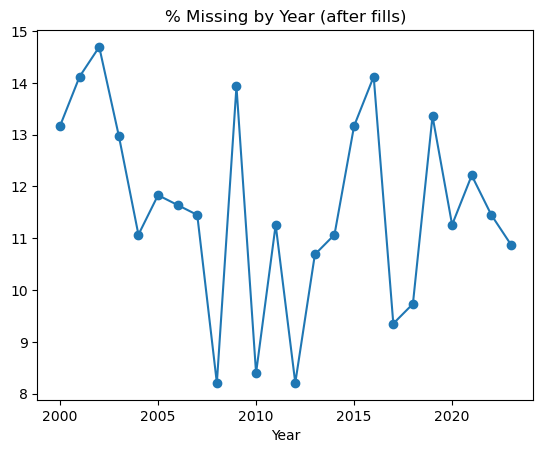

In [41]:
(df.groupby("Year")["Value"].apply(lambda x: x.isna().mean()*100)
   .plot(kind="line", marker="o", title="% Missing by Year (after fills)"))


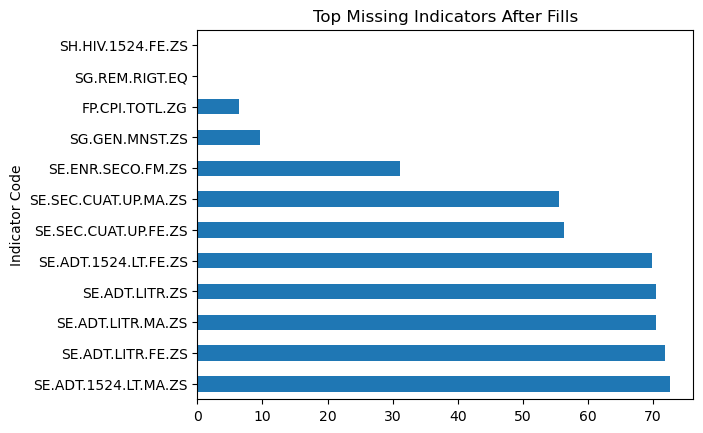

In [42]:
post = (df.groupby("Indicator Code")["Value"].apply(lambda x: x.isna().mean()*100)
          .sort_values(ascending=False).head(12))
post.plot(kind="barh", title="Top Missing Indicators After Fills"); 


In [43]:
gap_summary = (
    df.groupby(["Indicator Name", "Country"])
    .agg(
        total_points=("Value", "size"),
        nulls=("Value", lambda x: x.isna().sum()),
        first_year=("Year", "min"),
        last_year=("Year", "max")
    )
)
gap_summary["missing_rate"] = gap_summary["nulls"] / gap_summary["total_points"]
gap_summary.sort_values("missing_rate", ascending=False).head(10)


total_points  \
Indicator Name                                     Country                     
Literacy rate, youth male (% of males ages 15-24)  Yemen, Rep.            24   
Literacy rate, adult female (% of females ages ... Yemen, Rep.            24   
Educational attainment, at least completed uppe... Yemen, Rep.            24   
Educational attainment, at least completed uppe... Yemen, Rep.            24   
Literacy rate, youth male (% of males ages 15-24)  Algeria                24   
                                                   Bahrain                24   
Educational attainment, at least completed uppe... Morocco                24   
Literacy rate, youth female (% of females ages ... Bahrain                24   
Literacy rate, adult male (% of males ages 15 a... Bahrain                24   
                                                   Algeria                24   

                                                                nulls  \
Indicator Name                                     Country              
Literacy rate, youth male (% of males ages 15-24)  Yemen, Rep.     23   
Literacy rate, adult female (% of females ages ... Yemen, Rep.     23   
Educational attainment, at least completed uppe... Yemen, Rep.     22   
Educational attainment, at least completed uppe... Yemen, Rep.     22   
Literacy rate, youth male (% of males ages 15-24)  Algeria         21   
                                                   Bahrain         21   
Educational attainment, at least completed uppe... Morocco         21   
Literacy rate, youth female (% of females ages ... Bahrain         21   
Literacy rate, adult male (% of males ages 15 a... Bahrain         21   
                                                   Algeria         21   

                                                                first_year  \
Indicator Name                                     Country                   
Literacy rate, youth male (% of males ages 15-24)  Yemen, Rep.        2000   
Literacy rate, adult female (% of females ages ... Yemen, Rep.        2000   
Educational attainment, at least completed uppe... Yemen, Rep.        2000   
Educational attainment, at least completed uppe... Yemen, Rep.        2000   
Literacy rate, youth male (% of males ages 15-24)  Algeria            2000   
                                                   Bahrain            2000   
Educational attainment, at least completed uppe... Morocco            2000   
Literacy rate, youth female (% of females ages ... Bahrain            2000   
Literacy rate, adult male (% of males ages 15 a... Bahrain            2000   
                                                   Algeria            2000   

                                                                last_year  \
Indicator Name                                     Country                  
Literacy rate, youth male (% of males ages 15-24)  Yemen, Rep.       2023   
Literacy rate, adult female (% of females ages ... Yemen, Rep.       2023   
Educational attainment, at least completed uppe... Yemen, Rep.       2023   
Educational attainment, at least completed uppe... Yemen, Rep.       2023   
Literacy rate, youth male (% of males ages 15-24)  Algeria           2023   
                                                   Bahrain           2023   
Educational attainment, at least completed uppe... Morocco           2023   
Literacy rate, youth female (% of females ages ... Bahrain           2023   
Literacy rate, adult male (% of males ages 15 a... Bahrain           2023   
                                                   Algeria           2023   

                                                                missing_rate  
Indicator Name                                     Country                    
Literacy rate, youth male (% of males ages 15-24)  Yemen, Rep.      0.958333  
Literacy rate, adult female (% of females ages ... Yemen, Rep.      0.958333  
Educational attainment, at least completed uppe.

In [44]:
df[df['Value'].isna()]["Indicator Name"].value_counts()

Indicator Name
Literacy rate, youth male (% of males ages 15-24)                                                      209
Literacy rate, adult female (% of females ages 15 and above)                                           207
Literacy rate, youth female (% of females ages 15-24)                                                  201
Literacy rate, adult male (% of males ages 15 and above)                                               186
Literacy rate, adult total (% of people ages 15 and above)                                             186
Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)    162
Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)      160
School enrollment, secondary (gross), gender parity index (GPI)                                         97
Proportion of women in ministerial level positions (%)                                                  30
Inflation, consumer pr

In [45]:
df[df["Value"].isna()]["Country"].value_counts()


Country
Yemen, Rep.         145
Morocco             145
Iraq                144
Algeria             143
Saudi Arabia        138
Bahrain             137
Oman                116
Jordan              111
Kuwait               95
Qatar                91
Egypt, Arab Rep.     78
Tunisia              78
Libya                37
Name: count, dtype: int64

##### For Inflation (%) and School enrollment GPI:
Safe to interpolate (linear or polynomial) since they vary smoothly over time.

In [46]:
df.loc[df["Indicator Name"].isin(["Inflation, consumer prices (annual %)", 
                                  "School enrollment, secondary (gross), gender parity index (GPI)"]),
       "Value"] = df.groupby(["Country", "Indicator Name"])["Value"].transform(lambda x: x.interpolate())


##### For Women in ministerial positions (%):
These fluctuate abruptly (e.g., after elections). Do not interpolate. Either keep nulls or use last observation carried forward if the gap is ≤2 years:

In [47]:
df.loc[df["Indicator Name"] == "Proportion of women in ministerial level positions (%)", 
       "Value"] = df.groupby("Country")["Value"].transform(lambda x: x.ffill(limit=2))


#### Literacy & Education (6 indicators):
Usually sparse in early years (2000–2005) for many MENA countries — UNESCO/World Bank data gaps.
-Pattern: Country-specific missing years (esp. Yemen, Iraq, Libya).
-Meaning: These are structural gaps, not random — they reflect data unavailability, not error.

Recommendation:
-Keep them. Don’t fill with artificial estimates, because these values feed into social development metrics (e.g., HCI, WBL correlations).
-Instead, flag them in Tableau as “No Data Reported.”

In [48]:
remaining = df["Value"].isna().sum()
pct = remaining / len(df) * 100
print(f"✅ Remaining nulls after final fills: {remaining} ({pct:.2f}%)")


✅ Remaining nulls after final fills: 1342 (10.67%)


In [49]:
gap_summary = (
    df.groupby(["Indicator Name", "Country"])
    .agg(
        total_points=("Value", "size"),
        nulls=("Value", lambda x: x.isna().sum()),
        first_year=("Year", "min"),
        last_year=("Year", "max")
    )
)
gap_summary["missing_rate"] = gap_summary["nulls"] / gap_summary["total_points"]
gap_summary.sort_values("missing_rate", ascending=False).head(10)


,,total_points,nulls,first_year,last_year,missing_rate
Indicator Name,Country,,,,,
"Literacy rate, youth male (% of males ages 15-24)","Yemen, Rep.",24,23,2000,2023,0.958333
"Literacy rate, adult female (% of females ages 15 and above)","Yemen, Rep.",24,23,2000,2023,0.958333
"Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)","Yemen, Rep.",24,22,2000,2023,0.916667
"Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)","Yemen, Rep.",24,22,2000,2023,0.916667
"Literacy rate, youth female (% of females ages 15-24)","Yemen, Rep.",24,21,2000,2023,0.875000
"Literacy rate, adult male (% of males ages 15 and above)",Bahrain,24,21,2000,2023,0.875000
"Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)",Morocco,24,21,2000,2023,0.875000
"Literacy rate, youth female (% of females ages 15-24)",Bahrain,24,21,2000,2023,0.875000
"Literacy rate, adult male (% of males ages 15 and above)",Algeria,24,21,2000,2023,0.875000


In [52]:
df["missing_rate"] = df.groupby("Indicator Name")["Value"].transform(lambda x: x.isna().mean())


In [53]:
df.head()

,Country,Country Code,Year,Indicator Code,Indicator Name,Value,Unit Type,missing_rate
0,Algeria,DZ,2000,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",2.311499,Percent (%),0.035256
1,Algeria,DZ,2001,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",2.311499,Percent (%),0.035256
2,Algeria,DZ,2002,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",2.311499,Percent (%),0.035256
3,Algeria,DZ,2003,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",2.311499,Percent (%),0.035256
4,Algeria,DZ,2004,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",2.311499,Percent (%),0.035256


In [54]:
print(f"Remaining nulls: {df['Value'].isna().sum()} ({df['Value'].isna().mean()*100:.2f}%)")


Remaining nulls: 1342 (10.67%)
